In [1]:
!pip install ruptures

In [2]:
!pip install statsmodels

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import ruptures as rpt
from scipy.stats import entropy
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from sklearn.neighbors import NearestNeighbors
from statsmodels.tsa.stattools import adfuller

[*********************100%***********************]  1 of 1 completed

/Users/lucaliu/opt/anaconda3/lib/python3.9/site-packages/yfinance/utils.py:689: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')


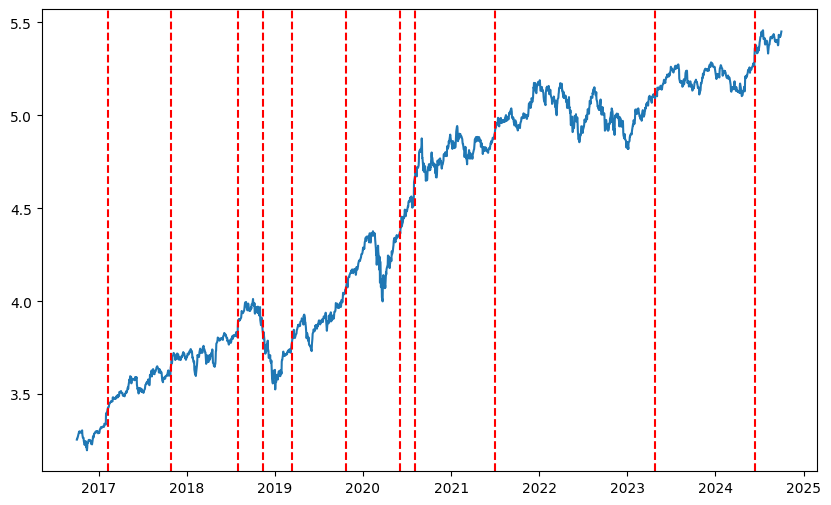

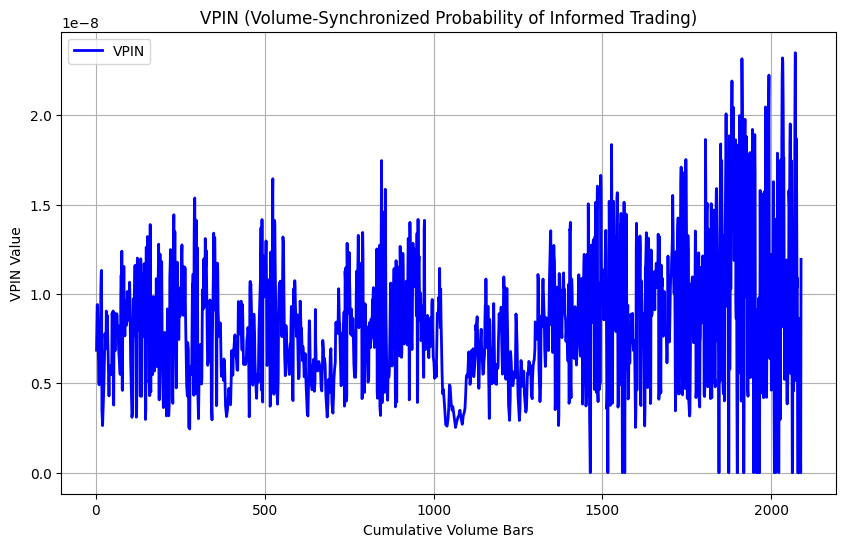

                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2024-09-24  228.649994  229.350006  225.729996  227.369995  227.369995   
2024-09-25  224.929993  227.289993  224.020004  226.369995  226.369995   
2024-09-26  227.300003  228.500000  225.410004  227.520004  227.520004   
2024-09-27  228.460007  229.520004  227.300003  227.789993  227.789993   
2024-09-30  230.039993  233.000000  229.649994  233.000000  233.000000   

              Volume  Log Stock Price  Log Returns   mid_price  \
Date                                                             
2024-09-24  43556100         5.426579     0.003966  227.540001   
2024-09-25  42308700         5.422171    -0.004408  225.654999   
2024-09-26  36636700         5.427238     0.005067  226.955002   
2024-09-27  34026000         5.428424     0.001186  228.410004   
2024-09-30  54541900         5.451038     0.022614  231.324997   

            Rollin

In [9]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ruptures as rpt
from statsmodels.tsa.stattools import adfuller
from sklearn.neighbors import NearestNeighbors
from scipy.stats import entropy

# Fetch data from Yahoo Finance
def fetch_data(ticker_symbol, start_date, end_date):
    stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)
    stock_data['Log Stock Price'] = np.log(stock_data['Adj Close'])
    stock_data['Log Returns'] = stock_data['Log Stock Price'].diff()
    return stock_data

# Apply CUSUM to detect structural breaks
def apply_cusum(stock_data, threshold=0.03):
    mean_value = stock_data['Log Returns'].mean()
    cumulative_sum = 0
    cusum_signal = []
    for price in stock_data['Log Returns'].dropna():
        cumulative_sum += price - mean_value
        if abs(cumulative_sum) > threshold:
            cusum_signal.append(1)
            cumulative_sum = 0  # Reset signal
        else:
            cusum_signal.append(0)
    stock_data['CUSUM Feature'] = pd.Series(cusum_signal, index=stock_data['Log Returns'].dropna().index)
    stock_data['CUSUM Feature'] = stock_data['CUSUM Feature'].reindex(stock_data.index, fill_value=0)
    return stock_data

# Detect structural breaks using Ruptures
def detect_breakpoints(stock_data, model="l2", pen=1):
    algo = rpt.Pelt(model=model).fit(stock_data['Log Stock Price'].dropna().values)
    breakpoints = algo.predict(pen=pen)
    breakpoints = stock_data.index[breakpoints[:-1]]  # Ensure index bounds
    stock_data['Structural Break'] = 0
    stock_data.loc[breakpoints, 'Structural Break'] = 1

    plt.figure(figsize=(10, 6))
    plt.plot(stock_data['Log Stock Price'], label="Log Stock Price")
    for bp in breakpoints:
        plt.axvline(x=bp, color='red', linestyle='--', label='Break Point')
    plt.show()

    return stock_data

# Rolling SADF feature
def rolling_sadf(stock_data, window=60):
    sadf_values = []
    for i in range(len(stock_data['Log Stock Price'].dropna()) - window + 1):
        sub_series = stock_data['Log Stock Price'].dropna().iloc[i:i + window]
        result = adfuller(sub_series)
        sadf_values.append(result[0])
    sadf_values = [np.nan] * (window - 1) + sadf_values
    stock_data['SADF Feature'] = pd.Series(sadf_values, index=stock_data['Log Stock Price'].dropna().index)
    return stock_data

# Lorentzian Classifier
def apply_lorentzian_classifier(stock_data, feature_columns, neighbors_count=8):
    X = stock_data[feature_columns].dropna().values
    stock_data_cleaned = stock_data.dropna(subset=feature_columns).copy()

    nbrs = NearestNeighbors(n_neighbors=neighbors_count, metric=lorentzian_distance)
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)

    prediction = np.sign(np.diff(stock_data_cleaned['Close'].values, prepend=np.nan))
    stock_data_cleaned['Prediction'] = prediction
    stock_data_cleaned['ANN_Prediction'] = np.nan

    for i in range(len(stock_data_cleaned)):
        neighbor_indices = indices[i]
        neighbor_votes = [stock_data_cleaned.iloc[idx]['Prediction'] for idx in neighbor_indices if idx < len(stock_data_cleaned)]
        if not neighbor_votes:
            continue
        stock_data_cleaned.iloc[i, stock_data_cleaned.columns.get_loc('ANN_Prediction')] = pd.Series(neighbor_votes).mode()[0]

    stock_data.loc[stock_data_cleaned.index, 'Prediction'] = stock_data_cleaned['Prediction']
    stock_data.loc[stock_data_cleaned.index, 'ANN_Prediction'] = stock_data_cleaned['ANN_Prediction']

    return stock_data

# Helper function for Lorentzian distance
def lorentzian_distance(x, y):
    return np.sum(np.log(1 + np.abs(x - y)))

# Corwin-Schultz Spread Estimator
def corwin_schultz(stock_data, sl=1):
    def get_beta(series, sl):
        hl = np.log(series['High'] / series['Low']) ** 2
        beta = hl.rolling(window=2).sum().rolling(window=sl).mean()
        return beta.dropna()

    def get_gamma(series):
        h2 = series['High'].rolling(window=2).max()
        l2 = series['Low'].rolling(window=2).min()
        gamma = np.log(h2 / l2) ** 2
        return gamma.dropna()

    def get_alpha(beta, gamma):
        den = 3 - 2 * 2 ** 0.5
        alpha = (2 ** 0.5 - 1) * (beta ** 0.5) / den
        alpha = -(gamma / den) ** 0.5
        return alpha.dropna()

    beta = get_beta(stock_data, sl)
    gamma = get_gamma(stock_data)
    alpha = get_alpha(beta, gamma)
    spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
    stock_data['Corwin-Schultz Spread'] = spread
    return stock_data

# Plot VPIN (Volume-Synchronized Probability of Informed Trading)
def plot_vpin(vpin_series):
    plt.figure(figsize=(10, 6))
    plt.plot(vpin_series.index, vpin_series.values, label='VPIN', color='blue', linewidth=2)
    plt.title('VPIN (Volume-Synchronized Probability of Informed Trading)')
    plt.xlabel('Cumulative Volume Bars')
    plt.ylabel('VPIN Value')
    plt.grid(True)
    plt.legend()
    plt.show()

# Calculate VPIN feature
def compute_vpin(volume_bars, window):
    order_imbalance = np.abs(volume_bars['trade_sign'])  # Absolute imbalance
    total_volume = volume_bars['Volume']
    vpin = order_imbalance.rolling(window).mean() / total_volume.rolling(window).mean()
    return vpin

# Classify trades using adjusted Close or Close instead of Bid/Ask
def classify_trades(stock_data):
    mid_price = stock_data['Adj Close']  # Use 'Adj Close' as a proxy for mid-price
    price_diff = mid_price.diff()
    trade_sign = np.sign(price_diff).fillna(0)
    trade_sign[trade_sign == 0] = trade_sign.shift(1)  # Carry forward the last trade sign if no change
    stock_data['trade_sign'] = trade_sign
    return stock_data

# Get volume bars
def get_volume_bars(stock_data, volume_threshold):
    stock_data['Cum_Volume'] = stock_data['Volume'].cumsum()
    bar_index = np.floor(stock_data['Cum_Volume'] / volume_threshold)

    volume_bars = stock_data.groupby(bar_index).agg({
        'Volume': 'sum',
        'Log Returns': 'sum',
        'Log Stock Price': 'last',
        'trade_sign': 'sum'
    })
    return volume_bars

# Rolling volatility in 20 days window
def calculate_rolling_volatility(stock_data, window_size=20):
    stock_data['mid_price'] = (stock_data['High'] + stock_data['Low']) / 2  # Calculate mid-price using High and Low
    stock_data['Rolling Volatility'] = stock_data['mid_price'].rolling(window=window_size).std()  # Rolling standard deviation
    return stock_data

# Big event indicators as indicator function 0 or 1
def big_event_indicator(stock_data, event_dates):
    """
    Add a binary indicator (0 or 1) for the occurrence of a big event.

    Parameters:
    - stock_data (pd.DataFrame): The stock data.
    - event_dates (list of str): List of event dates in 'YYYY-MM-DD' format.
    """
    big_event_indicator = np.zeros(len(stock_data))
    for event_date in event_dates:
        event_date = pd.Timestamp(event_date)  # Convert to pd.Timestamp
        big_event_indicator[(stock_data.index >= event_date) & (stock_data.index < event_date + pd.Timedelta(hours=1))] = 1
    stock_data['Big Event Indicator'] = pd.Series(big_event_indicator, index=stock_data.index)
    return stock_data

# Fibonacci Retracement Levels
def apply_fibonacci_alpha_factors(stock_data):
    period_high = stock_data['High'].rolling(window=365, min_periods=1).max()
    period_low = stock_data['Low'].rolling(window=365, min_periods=1).min()

    for level in [0.236, 0.382, 0.5, 0.618, 0.786]:
        stock_data[f'Fib_Level_{level}'] = period_high - (period_high - period_low) * level

    return stock_data

# Function to calculate Simple Moving Average (SMA)
def sma(series, length):
    return series.rolling(window=length).mean()

# Function to calculate standard deviation
def stdev(series, length):
    return series.rolling(window=length).std()

# Function to calculate True Range (TR)
def true_range(high, low, close):
    return np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))

# Function to calculate the Squeeze Momentum Indicator
def squeeze_momentum_numeric(stock_data, length=20, mult=2.0, lengthKC=20, multKC=1.5, useTrueRange=True):
    # Calculate BB (Bollinger Bands)
    source = stock_data['Close']
    basis = sma(source, length)
    dev = mult * stdev(source, length)
    upperBB = basis + dev
    lowerBB = basis - dev

    # Calculate KC (Keltner Channel)
    ma = sma(source, lengthKC)
    if useTrueRange:
        range_ = true_range(stock_data['High'], stock_data['Low'], stock_data['Close'])
    else:
        range_ = stock_data['High'] - stock_data['Low']
    rangema = sma(range_, lengthKC)
    upperKC = ma + rangema * multKC
    lowerKC = ma - rangema * multKC

    # Squeeze conditions
    sqzOn = (lowerBB > lowerKC) & (upperBB < upperKC)
    sqzOff = (lowerBB < lowerKC) & (upperBB > upperKC)
    noSqz = ~(sqzOn | sqzOff)

    # Linear regression
    val = (source - (stock_data['High'].rolling(window=lengthKC).max() + stock_data['Low'].rolling(window=lengthKC).min()) / 2).rolling(window=lengthKC).apply(lambda x: np.polyfit(np.arange(lengthKC), x, 1)[0], raw=True)

    # Adding only the Squeeze Momentum numeric value to the DataFrame
    stock_data['sqz_momentum'] = val

    return stock_data


def true_range(high, low, close):
    tr = np.maximum(np.maximum(high - low, np.abs(high - close.shift(1))), np.abs(low - close.shift(1)))
    return tr

# Function to calculate Directional Movement Plus (DM+)
def directional_movement_plus(high, low):
    up_move = high - high.shift(1)
    down_move = low.shift(1) - low
    dm_plus = np.where((up_move > down_move) & (up_move > 0), up_move, 0)
    return dm_plus

# Function to calculate Directional Movement Minus (DM-)
def directional_movement_minus(high, low):
    up_move = high - high.shift(1)
    down_move = low.shift(1) - low
    dm_minus = np.where((down_move > up_move) & (down_move > 0), down_move, 0)
    return dm_minus

# Function to calculate ADX
def calculate_adx(stock_data, length=14, epsilon=1e-10):
    high = stock_data['High']
    low = stock_data['Low']
    close = stock_data['Close']

    # Calculate True Range, Directional Movement Plus and Minus
    tr = true_range(high, low, close)
    dm_plus = directional_movement_plus(high, low)
    dm_minus = directional_movement_minus(high, low)

    # Calculate DI+ and DI- using the smoothed values and avoid NaN issues
    di_plus = (dm_plus / tr) * 100
    di_minus = (dm_minus / tr) * 100

    # Calculate DX and ADX
    dx = (np.abs(di_plus - di_minus) / (di_plus + di_minus).replace(0, epsilon)) * 100  # Avoid division by zero
    adx = dx.rolling(window=length).mean()

    # Add ADX result to DataFrame
    stock_data['ADX'] = adx

    return stock_data

# Main function integrating Fibonacci features and new volatility/event indicators
def main():
    ticker = "AAPL"
    start_date = "2016-10-01"
    end_date = "2024-10-01"

    # Fetch and process data
    stock_data = fetch_data(ticker, start_date, end_date)

    # Apply new features
    stock_data = calculate_rolling_volatility(stock_data, window_size=20)
    event_dates = ['2018-12-24', '2020-03-16']  # Example big event dates
    stock_data = big_event_indicator(stock_data, event_dates)

    # Apply existing features
    stock_data = apply_cusum(stock_data)
    stock_data = detect_breakpoints(stock_data)
    stock_data = rolling_sadf(stock_data)
    stock_data = corwin_schultz(stock_data)
    stock_data = classify_trades(stock_data)
    stock_data = apply_fibonacci_alpha_factors(stock_data)
    stock_data = squeeze_momentum_numeric(stock_data)
    stock_data = calculate_adx(stock_data)

    # Get volume bars and compute VPIN
    volume_bars = get_volume_bars(stock_data, volume_threshold=100000000)
    vpin_series = compute_vpin(volume_bars, window=2)
    plot_vpin(vpin_series)

    # Print the final DataFrame with new features
    print(stock_data.tail())

if __name__ == "__main__":
    main()